In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


X, y = make_blobs(
    n_samples=300,
    centers=[
        [-2, -2],
        [2, -2],
        [0, 2]
    ],
    cluster_std=1.0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
from scipy.optimize import minimize


class LinearSVM:

    def __init__(self, C=1.0):
        self.C = C
        self.w = None
        self.b = None

    def fit(self, X, y):

        n_samples, n_features = X.shape

        def objective(theta):

            w = theta[:n_features]
            xi = theta[n_features + 1:]

            return (
                0.5 * np.dot(w, w)
                + self.C * np.sum(xi)
            )

        def constraints(theta):

            w = theta[:n_features]
            b = theta[n_features]
            xi = theta[n_features + 1:]

            return (
                y * (X @ w + b)
                + xi
                - 1
            )
        w0 = np.zeros(n_features)
        b0 = 0

        predictions = X @ w0 + b0

        xi0 = np.maximum(
            1 - y * predictions,
            0
        )

        theta0 = np.concatenate([
            w0,
            [b0],
            xi0
        ])

        bounds = (
            [(None, None)] * (n_features + 1)
            + [(0, None)] * n_samples
        )

        result = minimize(
            objective,
            theta0,
            method="SLSQP",
            bounds=bounds,
            constraints={
                "type": "ineq",
                "fun": constraints
            },
            options={
                "ftol": 1e-8,
                "maxiter": 2000
            }
        )

        if not result.success:
            raise RuntimeError(result.message)

        theta = result.x

        self.w = theta[:n_features]
        self.b = theta[n_features]

        return self

    def decision_function(self, X):

        return X @ self.w + self.b

    def predict(self, X):

        return np.where(
            self.decision_function(X) >= 0,
            1,
            -1
        )

In [4]:
from itertools import combinations


class OneVsOneSVM:

    def __init__(self, C=1.0):
        self.C = C
        self.models = {}

    def fit(self, X, y):

        classes = np.unique(y)

        for class_a, class_b in combinations(classes, 2):

            mask = (
                (y == class_a)
                |
                (y == class_b)
            )

            X_pair = X[mask]
            y_pair = y[mask]
            binary_y = np.where(
                y_pair == class_a,
                1,
                -1
            )

            svm = LinearSVM(C=self.C)

            svm.fit(
                X_pair,
                binary_y
            )

            self.models[
                (class_a, class_b)
            ] = svm

        return self

    def predict(self, X):

        n_samples = X.shape[0]

        classes = np.unique(
            np.concatenate([
                np.array(pair)
                for pair in self.models.keys()
            ])
        )

        votes = np.zeros(
            (n_samples, len(classes))
        )

        class_to_index = {
            cls: i
            for i, cls in enumerate(classes)
        }

        for (class_a, class_b), svm in self.models.items():

            predictions = svm.predict(X)

            for i, prediction in enumerate(predictions):

                if prediction == 1:

                    votes[
                        i,
                        class_to_index[class_a]
                    ] += 1

                else:

                    votes[
                        i,
                        class_to_index[class_b]
                    ] += 1

        return classes[np.argmax(votes, axis=1)]

In [5]:
ovo = OneVsOneSVM(C=1.0)

ovo.fit(
    X_train,
    y_train
)

ovo_pred = ovo.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score

print(
    "OvO accuracy:",
    accuracy_score(y_test, ovo_pred)
)

OvO accuracy: 0.9333333333333333


In [7]:
from sklearn.svm import SVC

sklearn_ovo = SVC(
    kernel="linear",
    C=1.0
)

sklearn_ovo.fit(
    X_train,
    y_train
)

sklearn_ovo_pred = sklearn_ovo.predict(X_test)

print(
    "Sklearn OvO:",
    accuracy_score(
        y_test,
        sklearn_ovo_pred
    )
)

Sklearn OvO: 0.9333333333333333


In [8]:
def plot_decision_regions(model, X, y, title):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(grid)

    predictions = predictions.reshape(
        xx.shape
    )

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25,
        levels=np.arange(
            len(np.unique(y)) + 1
        ) - 0.5
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="k"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

    plt.show()

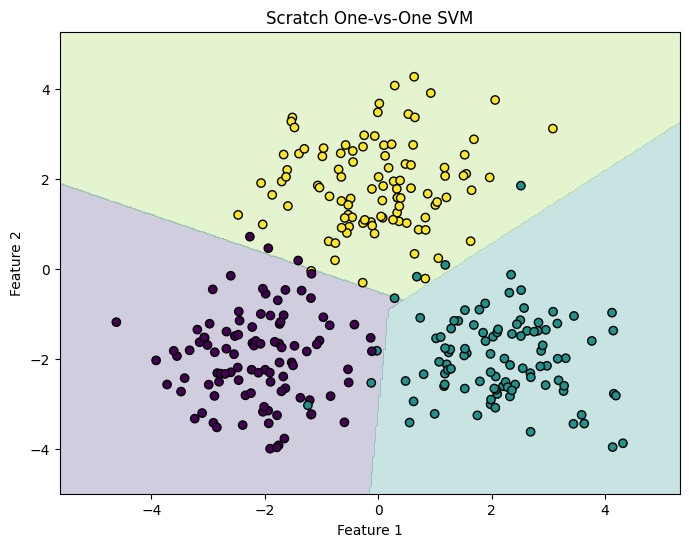

In [9]:
plot_decision_regions(
    ovo,
    X,
    y,
    "Scratch One-vs-One SVM"
)